# Wine Type Classification using Neural Networks

This notebook performs multi-class classification on the wine dataset by:
1. Loading the standard wine dataset from scikit-learn
2. Creating a neural network with mixed SELU and ReLU activations using PyTorch
3. Training the model to identify three different wine types
4. Evaluating classification accuracy on test data
5. Generating a confusion matrix to analyse classification performance

## Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load the Dataset

The wine dataset contains 178 samples across 3 cultivars, each described by
13 chemical measurements (alcohol content, flavonoids, colour intensity, etc.).
Labels are integer class indices — `CrossEntropyLoss` handles the softmax internally.

In [2]:
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)

## Define the Neural Network

Two hidden layers: 13 SELU units (matching the number of input features) followed by
5 ReLU units. The 3-unit linear output is passed to `CrossEntropyLoss`, which applies
`LogSoftmax` internally — no explicit softmax layer needed.

In [3]:
net = nn.Sequential(
    nn.Linear(X_train.shape[1], 13),
    nn.SELU(),
    nn.Linear(13, 5),
    nn.ReLU(),
    nn.Linear(5, 3),
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())

## Train the Model

In [4]:
for epoch in range(100):
    net.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(net(X_batch), y_batch)
        loss.backward()
        optimizer.step()

## Evaluate on Test Set

In [5]:
net.eval()
with torch.no_grad():
    preds = net(X_test_t).argmax(dim=1)
    accuracy = (preds == y_test_t).float().mean().item()

print(f"Test accuracy: {accuracy:.2f}")

Test accuracy: 0.94


## Confusion Matrix

Off-diagonal entries reveal which wine classes the network confuses most.
A perfect classifier would have all counts on the diagonal.

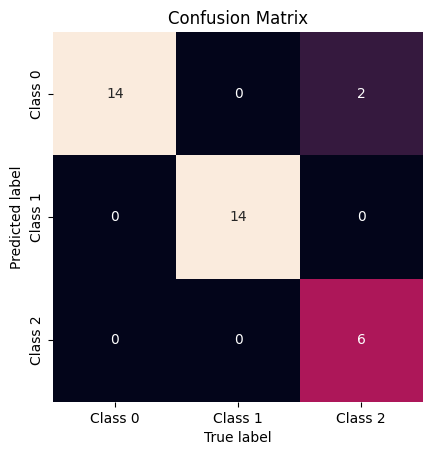

In [6]:
mat = confusion_matrix(y_test, preds.numpy())

sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('True label')
plt.ylabel('Predicted label')
plt.title('Confusion Matrix')
plt.show()